# Section 8: Preprocessing Policy and Image Transformation Design (v2 — Vignette Crop)
Defines and validates the deterministic image preprocessing pipeline. Now includes conditional inner-field crop to remove black dermoscope borders before resize-to-model-input. Does not define augmentation (Section 9) or data loading mechanics (Section 10).


In [2]:
%pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached keras-3.14.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   --------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
googleapis-common-protos 1.66.0 requires protobuf!=3.20.0,!=3.20.1,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0.dev0,>=3.20.2, but you have protobuf 7.34.1 which is incompatible.
google-api-core 2.24.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0.dev0,>=3.19.5, but you have protobuf 7.34.1 which is incompatible.
opentelemetry-proto 1.31.1 requires protobuf<6.0,>=5.0, but you have protobuf 7.34.1 which is incompatible.
proto-plus 1.26.0 requires protobuf<6.0.0dev,>=3.19.0, but you have protobuf 7.34.1 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 46.0.3 which is incompatible.
pydrive2 1.21.3 requires pyOpenSSL<=24.2.1,>=19.1.0, but you have pyopenssl 25.3.0 which is incompatible.
streamlit 1.41.1 requires pandas<3

In [1]:
%run 01_config.ipynb

import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
from IPython.display import display


Creating output structure in: D:\SKIN CANCER/pipeline_output
Set basic random seeds to 42.
No GPU detected. Processing on CPU.


## Load Split Manifests & Validate Counts


In [2]:
d_splits = os.path.join(OUTPUT_ROOT, "splits")
d_preprocess = os.path.join(OUTPUT_ROOT, "audit_reports", "preprocessing")
os.makedirs(d_preprocess, exist_ok=True)

df_train = pd.read_csv(os.path.join(d_splits, "train_manifest.csv"))
df_val = pd.read_csv(os.path.join(d_splits, "val_manifest.csv"))
df_test = pd.read_csv(os.path.join(d_splits, "test_manifest.csv"))

expected = {"train": 14171, "val": 2927, "test": 2957}
expected_class = {
    "train": {"NV": 8824, "MEL": 3104, "BCC": 2243},
    "val":   {"NV": 1805, "MEL": 663,  "BCC": 459},
    "test":  {"NV": 1887, "MEL": 607,  "BCC": 463}
}

splits = {"train": df_train, "val": df_val, "test": df_test}
errors = []

print("=== SECTION 8 INPUT DATASET VALIDATION ===")
for name, df in splits.items():
    actual = len(df)
    print(f"{name}: {actual} rows (Expected: {expected[name]})")
    if actual != expected[name]:
        errors.append(f"{name} row mismatch: expected {expected[name]}, got {actual}")
    counts = df["final_authoritative_label"].value_counts()
    for cls, exp_count in expected_class[name].items():
        act_count = counts.get(cls, 0)
        if act_count != exp_count:
            errors.append(f"{name}/{cls} mismatch: expected {exp_count}, got {act_count}")

if errors:
    raise ValueError(
        "Section 8 must run on the frozen split manifests, but mismatches were found:\n- "
        + "\n- ".join(errors)
    )

print("\nAll split manifest counts match expected frozen state.")


=== SECTION 8 INPUT DATASET VALIDATION ===
train: 14171 rows (Expected: 14171)
val: 2927 rows (Expected: 2927)
test: 2957 rows (Expected: 2957)

All split manifest counts match expected frozen state.


## Define Preprocessing Policy Constants


In [3]:
PREPROCESS_TARGET_SIZE = IMAGE_SIZE[0]  # 224 from config
PREPROCESS_INTERPOLATION = "bilinear"
PREPROCESS_COLOR_CHANNELS = 3
PREPROCESS_ASPECT_RATIO_STRATEGY = "vignette_crop_then_resize_shorter_then_center_crop"
PREPROCESS_ARTIFACT_SUPPRESSION = "conditional_vignette_crop_v2"

# Vignette crop constants
VIGNETTE_DARK_THRESHOLD = 40       # HSV V-channel: pixels below this are "black border"
VIGNETTE_MORPH_KERNEL_SIZE = 15     # Morphological cleanup kernel
VIGNETTE_OCCUPANCY_THRESHOLD = 0.65 # Row/col must have this fraction of valid pixels to be kept
VIGNETTE_SAFETY_PADDING_PCT = 0.03  # 3% padding inward from detected crop bounds
VIGNETTE_MIN_VALID_FRACTION = 0.30  # If valid mask covers less than this, skip crop (uncertain)
VIGNETTE_MAX_VALID_FRACTION = 0.92  # If valid mask covers more than this, skip crop (no vignette)
VIGNETTE_MIN_CROP_FRACTION = 0.40   # Crop must keep at least this fraction of original area

print("=== PREPROCESSING POLICY (v2 — Vignette Crop) ===")
print(f"Target size: {PREPROCESS_TARGET_SIZE}x{PREPROCESS_TARGET_SIZE}")
print(f"Interpolation: {PREPROCESS_INTERPOLATION}")
print(f"Color channels: {PREPROCESS_COLOR_CHANNELS}")
print(f"Aspect ratio strategy: {PREPROCESS_ASPECT_RATIO_STRATEGY}")
print(f"Artifact suppression: {PREPROCESS_ARTIFACT_SUPPRESSION}")
print(f"Vignette dark threshold (HSV-V): {VIGNETTE_DARK_THRESHOLD}")
print(f"Vignette occupancy threshold: {VIGNETTE_OCCUPANCY_THRESHOLD}")
print(f"Safety padding: {VIGNETTE_SAFETY_PADDING_PCT*100:.0f}%")


=== PREPROCESSING POLICY (v2 — Vignette Crop) ===
Target size: 224x224
Interpolation: bilinear
Color channels: 3
Aspect ratio strategy: vignette_crop_then_resize_shorter_then_center_crop
Artifact suppression: conditional_vignette_crop_v2
Vignette dark threshold (HSV-V): 40
Vignette occupancy threshold: 0.65
Safety padding: 3%


## Define Vignette Detection and Crop Function (OpenCV, Deterministic)


In [4]:
def detect_and_crop_vignette(img_bgr,
                              dark_thresh=VIGNETTE_DARK_THRESHOLD,
                              morph_k=VIGNETTE_MORPH_KERNEL_SIZE,
                              occupancy_thresh=VIGNETTE_OCCUPANCY_THRESHOLD,
                              safety_pad_pct=VIGNETTE_SAFETY_PADDING_PCT,
                              min_valid_frac=VIGNETTE_MIN_VALID_FRACTION,
                              max_valid_frac=VIGNETTE_MAX_VALID_FRACTION,
                              min_crop_frac=VIGNETTE_MIN_CROP_FRACTION):
    """
    Conditionally crop a dermoscopic image to remove black vignette borders.

    Uses HSV V-channel to build a valid-field mask, cleans with morphology,
    keeps the largest connected component, and derives crop bounds from
    row/column occupancy.

    Returns:
        cropped_bgr: numpy array, cropped image (or original if no crop).
        did_crop: bool, whether a crop was applied.
        crop_box: (y_start, y_end, x_start, x_end) or None.
        mask: binary mask (H, W) used for detection.
    """
    h, w = img_bgr.shape[:2]
    total_pixels = h * w

    # 1. Convert to HSV and threshold V-channel
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    v_channel = hsv[:, :, 2]
    mask = (v_channel > dark_thresh).astype(np.uint8) * 255

    # 2. Morphological cleanup: close small gaps, remove noise
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (morph_k, morph_k))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    # 3. Keep only the largest connected component (the dermoscope field)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if num_labels <= 1:
        return img_bgr, False, None, mask

    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    mask = ((labels == largest_label) * 255).astype(np.uint8)

    # 4. Check valid fraction
    valid_fraction = np.count_nonzero(mask) / total_pixels
    if valid_fraction < min_valid_frac or valid_fraction > max_valid_frac:
        return img_bgr, False, None, mask

    # 5. Derive crop bounds from row/column occupancy
    row_occupancy = np.count_nonzero(mask, axis=1) / w
    col_occupancy = np.count_nonzero(mask, axis=0) / h

    valid_rows = np.where(row_occupancy >= occupancy_thresh)[0]
    valid_cols = np.where(col_occupancy >= occupancy_thresh)[0]

    if len(valid_rows) == 0 or len(valid_cols) == 0:
        return img_bgr, False, None, mask

    y_start, y_end = int(valid_rows[0]), int(valid_rows[-1]) + 1
    x_start, x_end = int(valid_cols[0]), int(valid_cols[-1]) + 1

    # 6. Apply safety padding (inward)
    pad_y = int(h * safety_pad_pct)
    pad_x = int(w * safety_pad_pct)
    y_start = min(y_start + pad_y, h - 1)
    y_end = max(y_end - pad_y, y_start + 1)
    x_start = min(x_start + pad_x, w - 1)
    x_end = max(x_end - pad_x, x_start + 1)

    # 7. Verify crop keeps enough of the image
    crop_area = (y_end - y_start) * (x_end - x_start)
    if crop_area / total_pixels < min_crop_frac:
        return img_bgr, False, None, mask

    crop_box = (y_start, y_end, x_start, x_end)
    cropped = img_bgr[y_start:y_end, x_start:x_end].copy()

    return cropped, True, crop_box, mask


print("Vignette detection and crop function defined.")


Vignette detection and crop function defined.


## Vignette Crop Validation: Visual Examples Across Classes


=== VIGNETTE CROP EXAMPLES ===

NV sample 0: ISIC_0054107.jpg


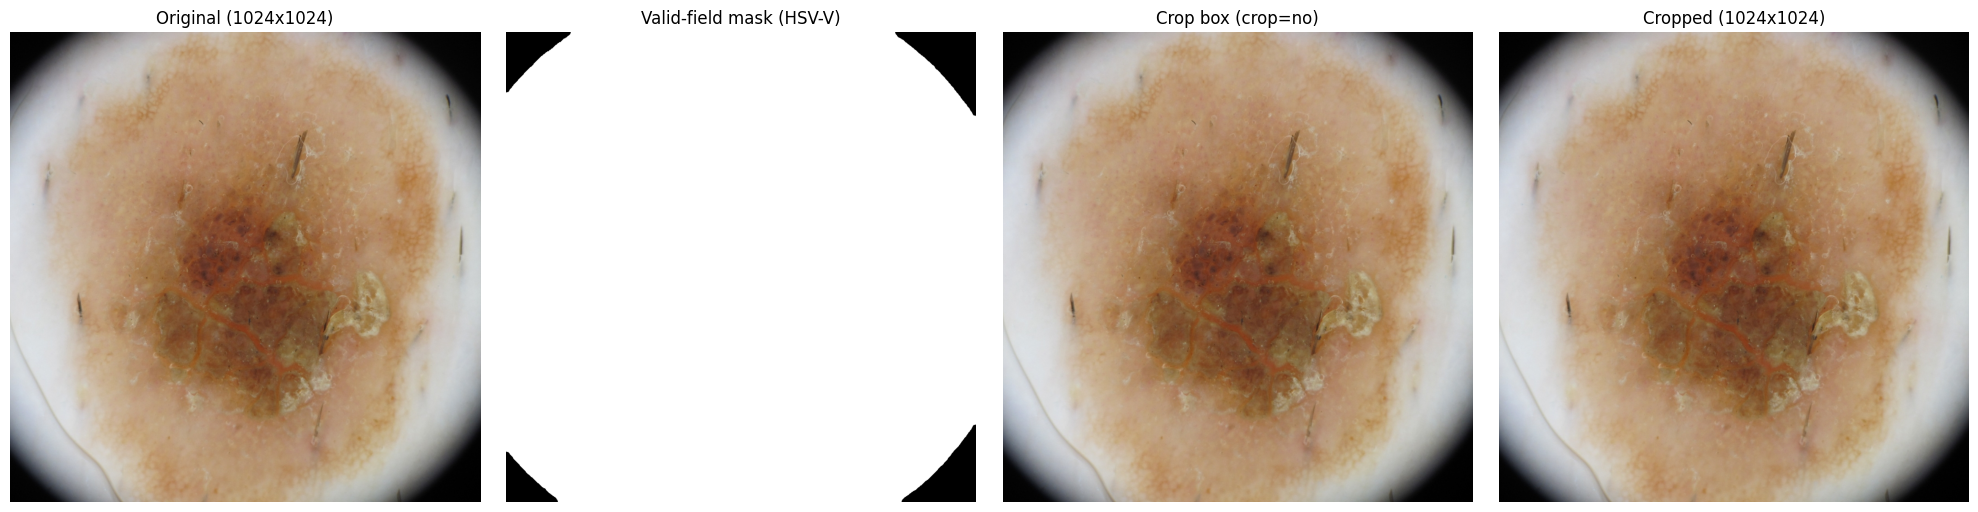


NV sample 1: ISIC_0025673.jpg


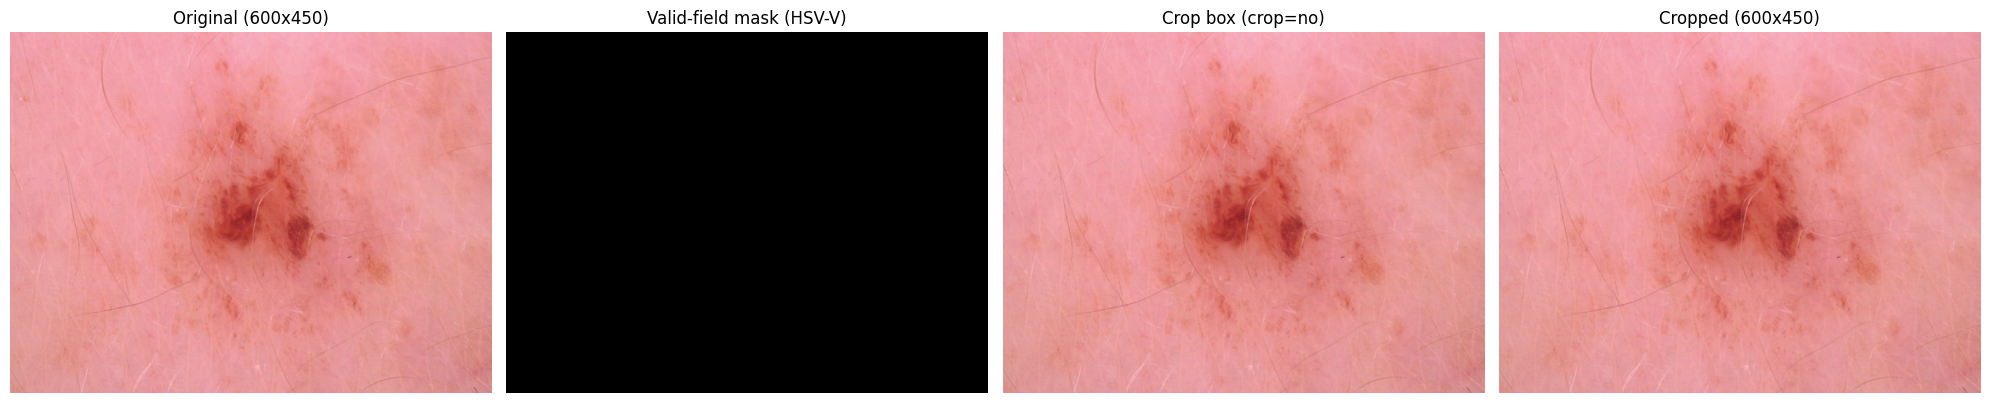


NV sample 2: ISIC_0025475.jpg


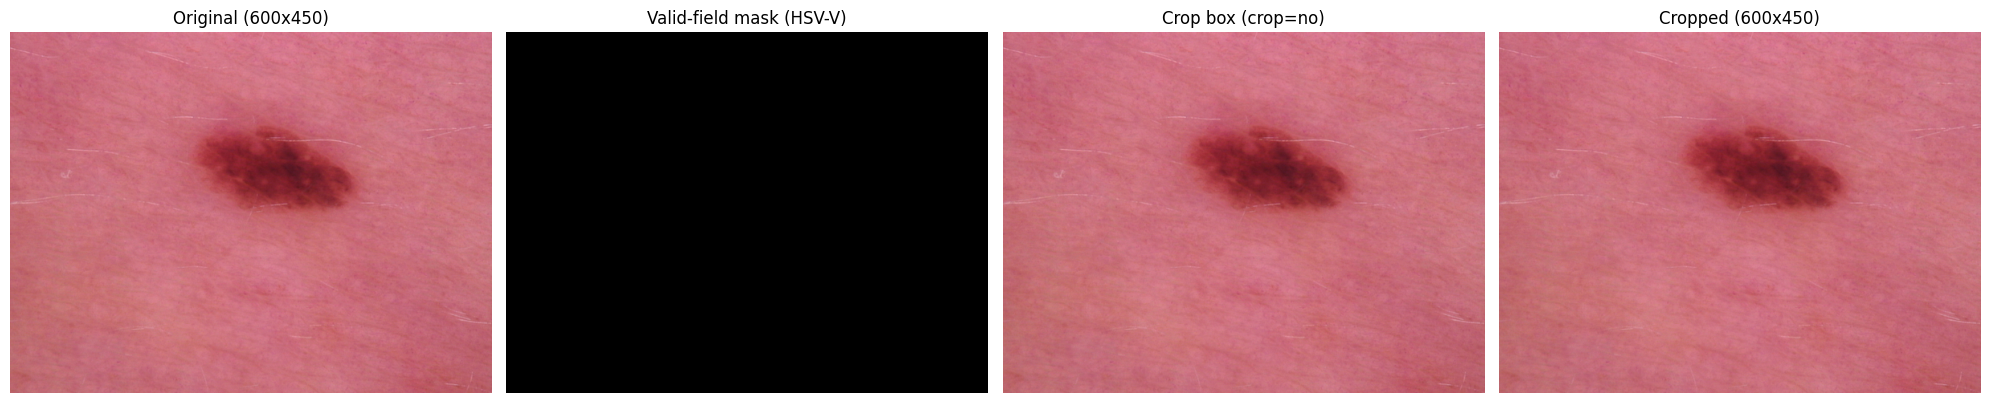


NV sample 3: ISIC_0059719.jpg


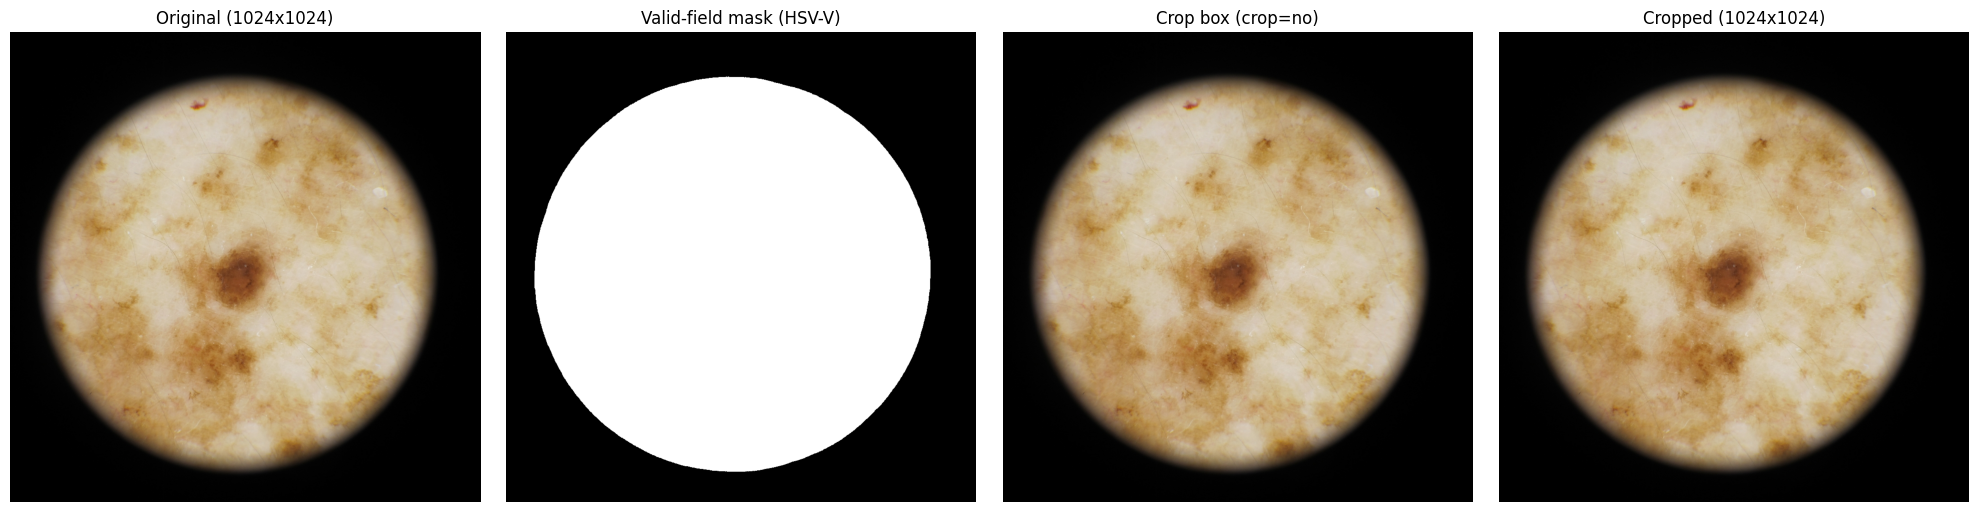


MEL sample 0: ISIC_0058716.jpg


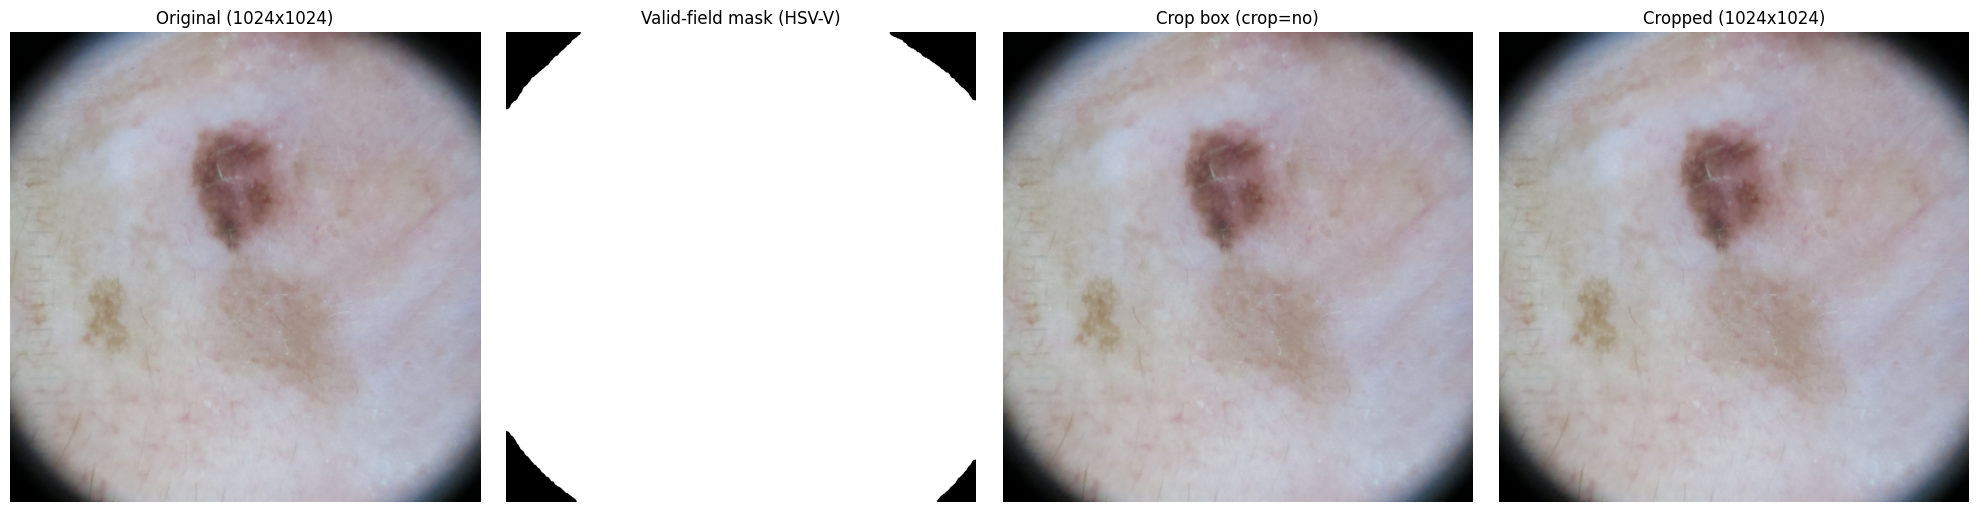


MEL sample 1: ISIC_0063829.jpg


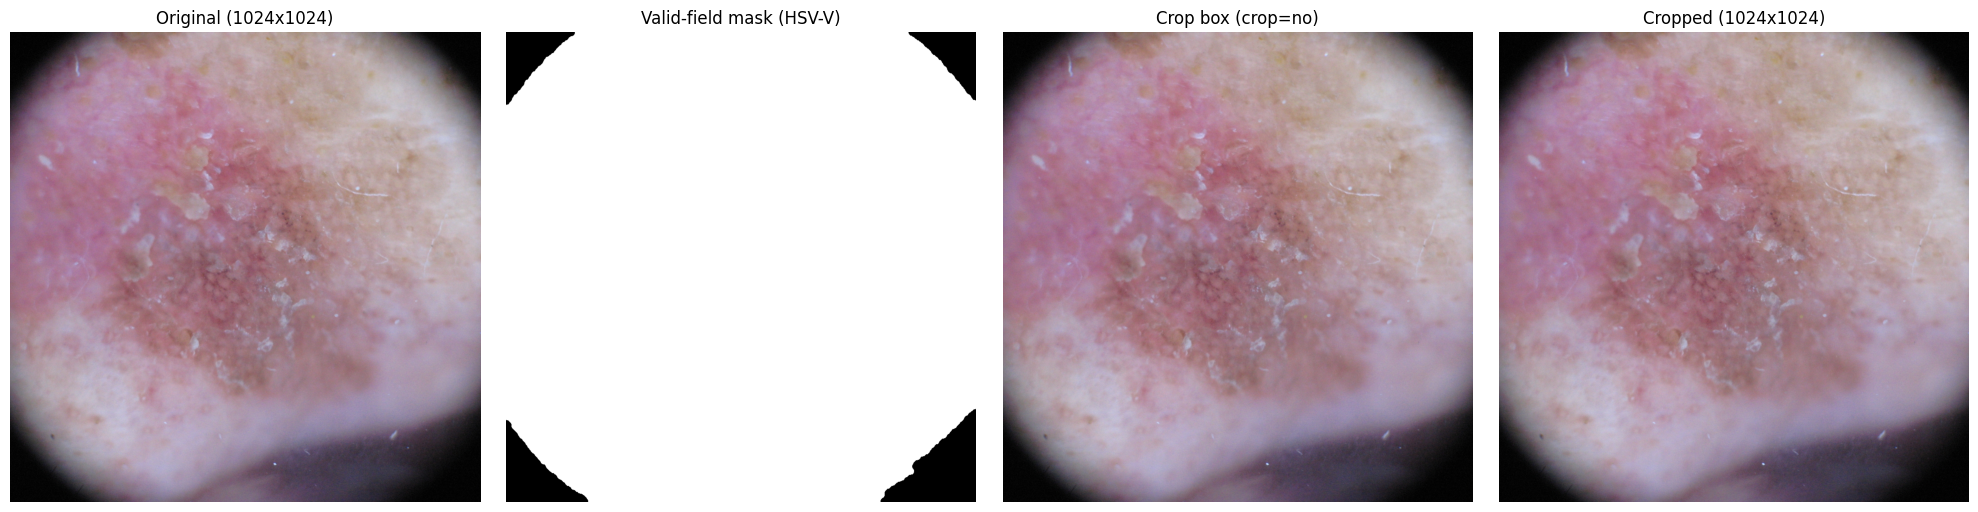


MEL sample 2: ISIC_0014862_downsampled.jpg


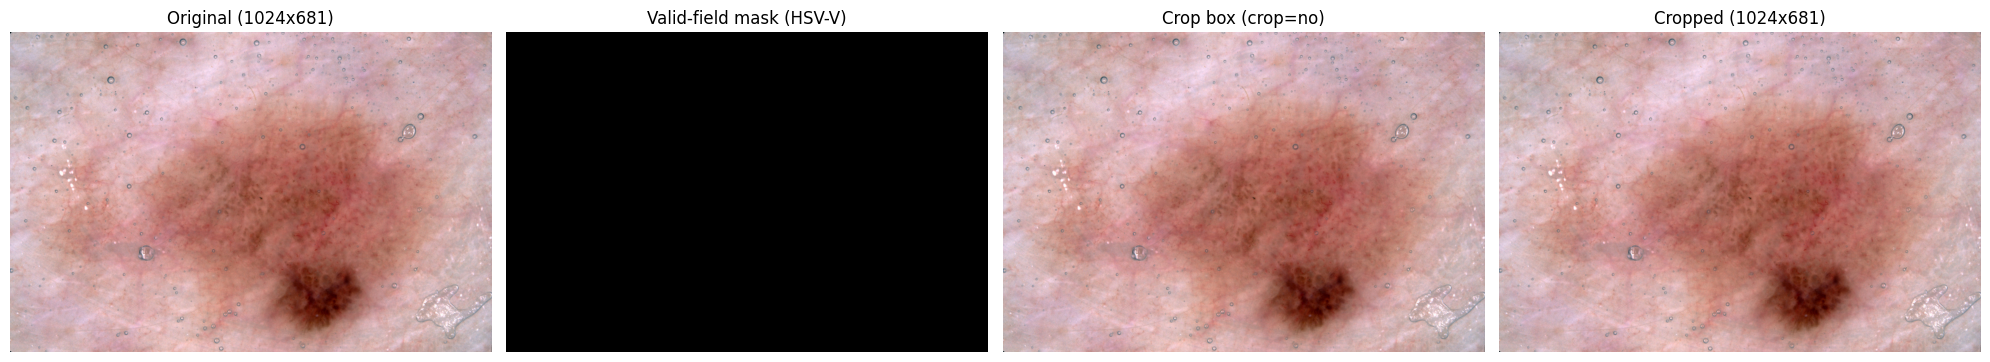


MEL sample 3: ISIC_0030929.jpg


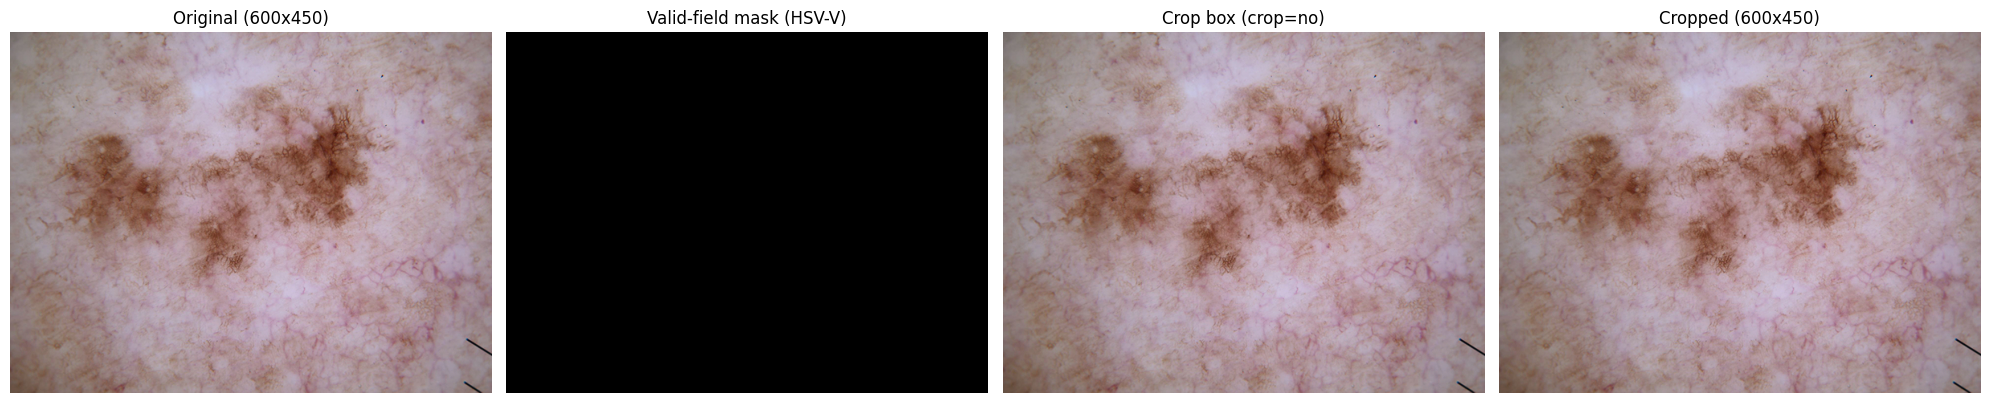


BCC sample 0: ISIC_0057569.jpg


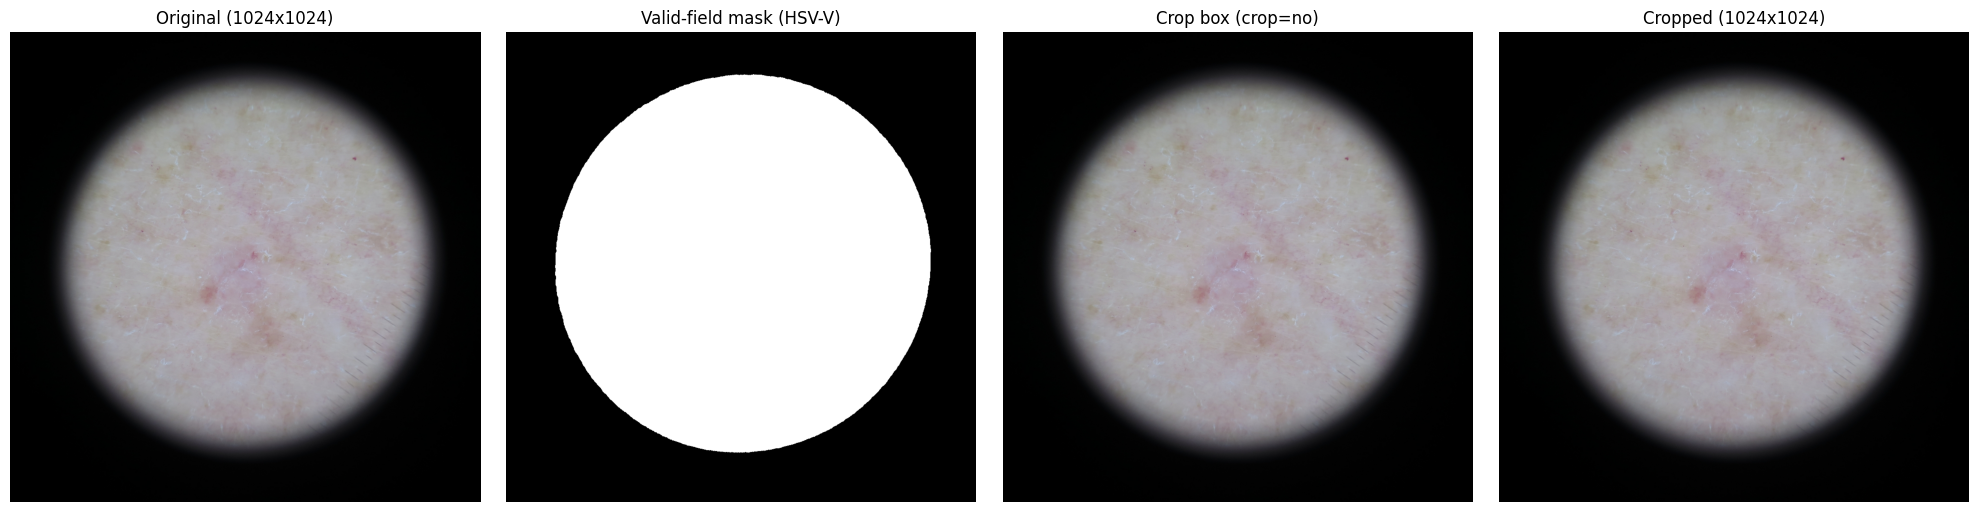


BCC sample 1: ISIC_0059491.jpg


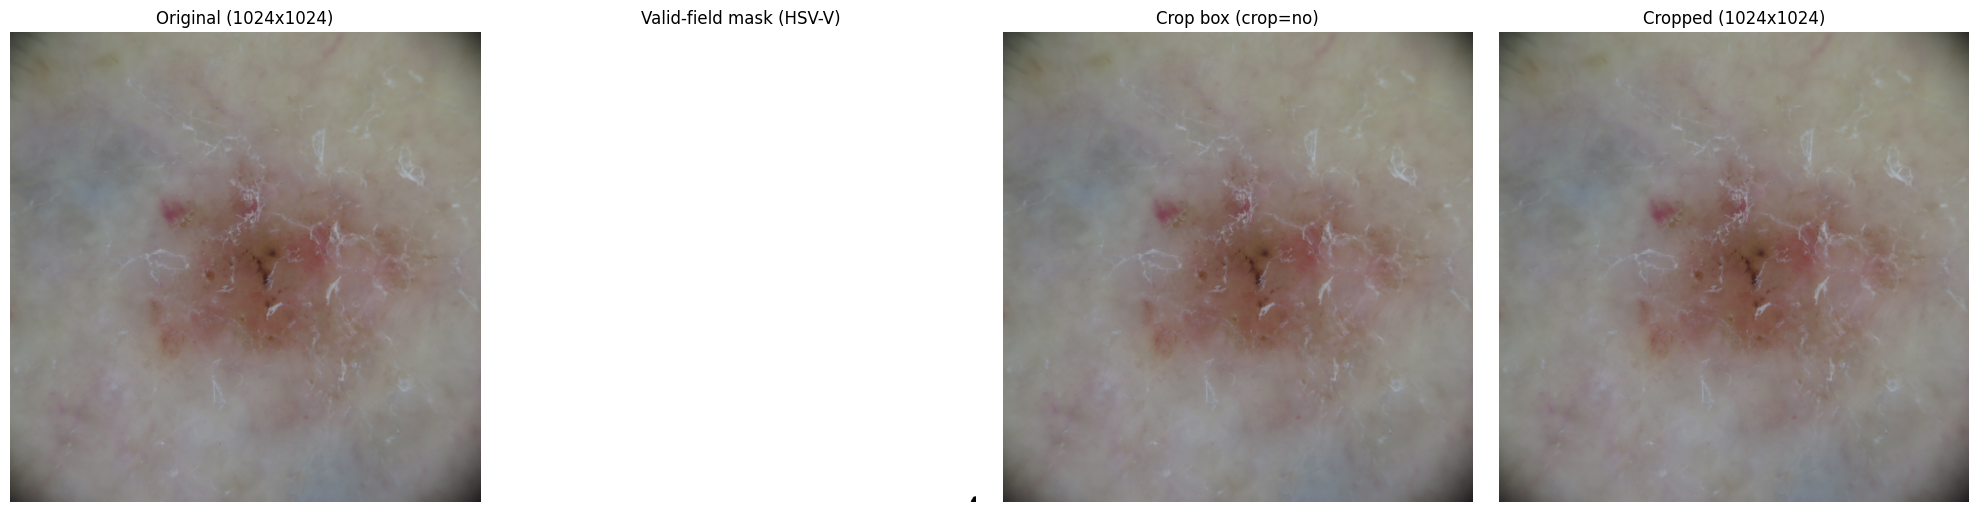


BCC sample 2: ISIC_0066119.jpg


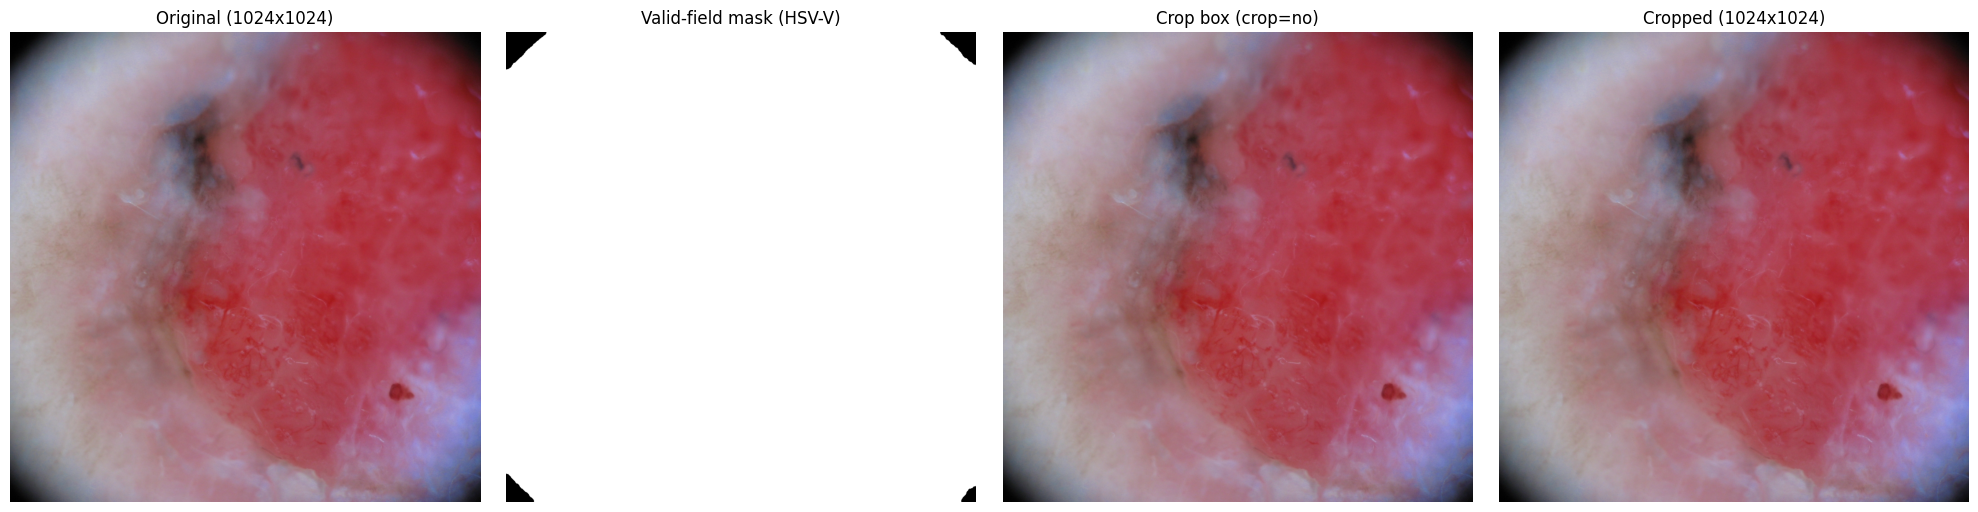


BCC sample 3: ISIC_0031284.jpg


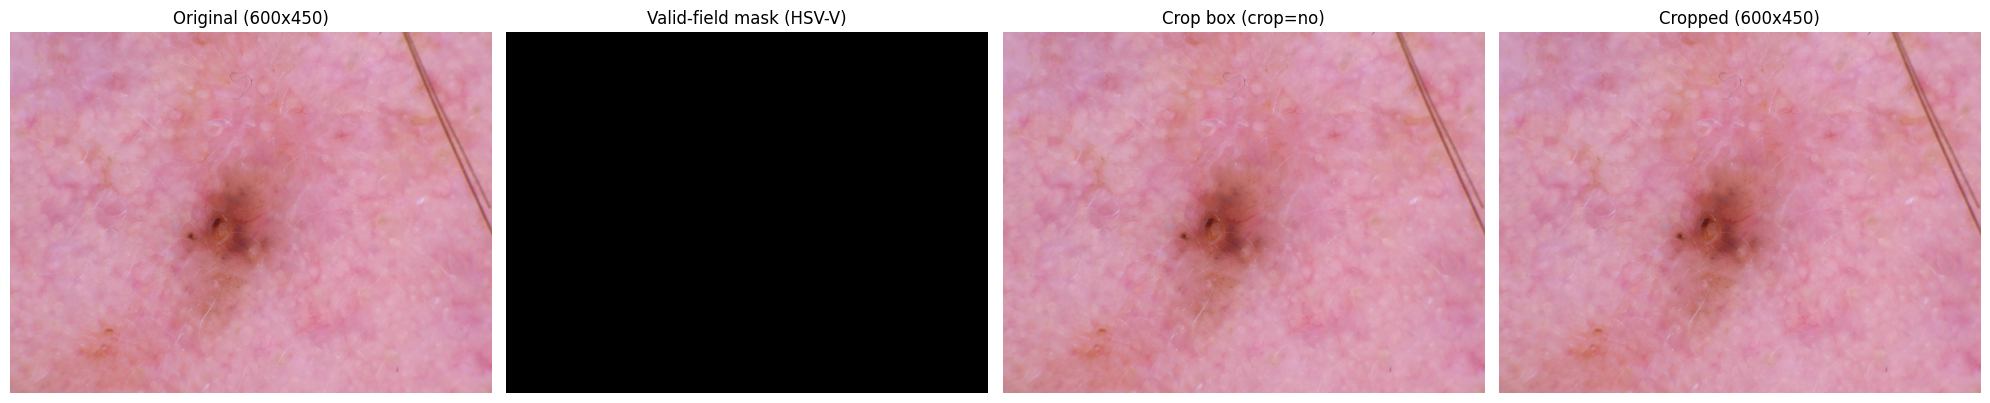

In [5]:
def visualize_vignette_crop(image_path, save_path=None):
    """Show original, mask, crop box overlay, and cropped output for one image."""
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f"Could not read: {image_path}")
        return None

    cropped, did_crop, crop_box, mask = detect_and_crop_vignette(img_bgr)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    cropped_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(img_rgb)
    axes[0].set_title(f"Original ({img_rgb.shape[1]}x{img_rgb.shape[0]})")
    axes[0].axis("off")

    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("Valid-field mask (HSV-V)")
    axes[1].axis("off")

    overlay = img_rgb.copy()
    if did_crop and crop_box is not None:
        y_s, y_e, x_s, x_e = crop_box
        cv2.rectangle(overlay, (x_s, y_s), (x_e, y_e), (0, 255, 0), 3)
    axes[2].imshow(overlay)
    axes[2].set_title(f"Crop box (crop={'yes' if did_crop else 'no'})")
    axes[2].axis("off")

    axes[3].imshow(cropped_rgb)
    axes[3].set_title(f"Cropped ({cropped_rgb.shape[1]}x{cropped_rgb.shape[0]})")
    axes[3].axis("off")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()
    return did_crop


print("=== VIGNETTE CROP EXAMPLES ===")
for cls in CLASS_NAMES:
    cls_df = df_train[df_train["final_authoritative_label"] == cls]
    sample = cls_df.sample(min(4, len(cls_df)), random_state=RANDOM_SEED)
    for i, (_, row) in enumerate(sample.iterrows()):
        save_name = f"vignette_example_{cls}_{i}.png"
        print(f"\n{cls} sample {i}: {os.path.basename(row['full_path'])}")
        visualize_vignette_crop(row["full_path"], os.path.join(d_preprocess, save_name))


## Run Vignette Detection on Full Dataset (Statistics Only)


In [6]:
from tqdm import tqdm

print("Running vignette detection across entire dataset (detection stats only)...")

all_paths = pd.concat([df_train, df_val, df_test])
vignette_stats = []

for _, row in tqdm(all_paths.iterrows(), total=len(all_paths), desc="Vignette scan"):
    img_bgr = cv2.imread(row["full_path"])
    if img_bgr is None:
        vignette_stats.append({"path": row["full_path"], "class": row["final_authoritative_label"],
                               "did_crop": False, "read_error": True})
        continue
    _, did_crop, crop_box, _ = detect_and_crop_vignette(img_bgr)
    h, w = img_bgr.shape[:2]
    if crop_box:
        y_s, y_e, x_s, x_e = crop_box
        crop_frac = ((y_e - y_s) * (x_e - x_s)) / (h * w)
    else:
        crop_frac = 1.0
    vignette_stats.append({
        "path": row["full_path"],
        "class": row["final_authoritative_label"],
        "did_crop": did_crop,
        "crop_frac": round(crop_frac, 4),
        "read_error": False
    })

df_vignette = pd.DataFrame(vignette_stats)
df_vignette.to_csv(os.path.join(d_preprocess, "vignette_detection_stats.csv"), index=False)

total_cropped = df_vignette["did_crop"].sum()
total_images = len(df_vignette)

print(f"\n=== VIGNETTE DETECTION SUMMARY ===")
print(f"Total images scanned: {total_images}")
print(f"Images where crop was applied: {total_cropped} ({100*total_cropped/total_images:.1f}%)")
print(f"Images left unchanged: {total_images - total_cropped}")

print("\n=== CROP RATE BY CLASS ===")
class_crop_stats = df_vignette.groupby("class").agg(
    total=("did_crop", "count"),
    cropped=("did_crop", "sum"),
    mean_crop_frac=("crop_frac", "mean")
).reset_index()
class_crop_stats["crop_pct"] = (100 * class_crop_stats["cropped"] / class_crop_stats["total"]).round(1)
display(class_crop_stats)


Running vignette detection across entire dataset (detection stats only)...


Vignette scan: 100%|██████████| 20055/20055 [04:06<00:00, 81.40it/s] 


=== VIGNETTE DETECTION SUMMARY ===
Total images scanned: 20055
Images where crop was applied: 1407 (7.0%)
Images left unchanged: 18648

=== CROP RATE BY CLASS ===


,class,total,cropped,mean_crop_frac,crop_pct
0,BCC,3165,462,0.944376,14.6
1,MEL,4374,442,0.960695,10.1
2,NV,12516,503,0.985450,4.0


## Define Updated Preprocessing Function (with Vignette Crop)


In [7]:
def preprocess_image_with_vignette_crop(image_path_str):
    """
    Full preprocessing: vignette crop (OpenCV) -> resize shorter side -> center crop -> normalize.
    Python-level function for use with tf.py_function.
    """
    target_size = PREPROCESS_TARGET_SIZE

    img_bgr = cv2.imread(image_path_str)
    if img_bgr is None:
        return np.zeros((target_size, target_size, 3), dtype=np.float32)

    # Conditional vignette crop
    img_bgr, _, _, _ = detect_and_crop_vignette(img_bgr)

    # BGR -> RGB
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)

    # Resize shorter side to target_size
    h, w = img_rgb.shape[:2]
    scale = target_size / min(h, w)
    new_h = int(np.ceil(h * scale))
    new_w = int(np.ceil(w * scale))
    img_rgb = cv2.resize(img_rgb, (new_w, new_h), interpolation=cv2.INTER_LINEAR)

    # Center crop
    start_y = (new_h - target_size) // 2
    start_x = (new_w - target_size) // 2
    img_rgb = img_rgb[start_y:start_y + target_size, start_x:start_x + target_size]

    # Normalize to [0, 1]
    img_rgb = img_rgb / 255.0

    return img_rgb.astype(np.float32)


def preprocess_image(image_path, target_size=PREPROCESS_TARGET_SIZE, preprocess_fn=None):
    """
    tf.data-compatible wrapper: runs vignette crop via tf.py_function,
    then optionally applies backbone-specific normalization.
    """
    def _py_preprocess(path_tensor):
        path_str = path_tensor.numpy().decode("utf-8")
        return preprocess_image_with_vignette_crop(path_str)

    image = tf.py_function(_py_preprocess, [image_path], tf.float32)
    image.set_shape((target_size, target_size, 3))

    if preprocess_fn is not None:
        # Backbone preprocess_input expects [0, 255], undo our /255
        image = image * 255.0
        image = preprocess_fn(image)

    return image


def preprocess_image_default(image_path):
    """Wrapper with default normalization (scale to [0, 1]) for tf.data.map compatibility."""
    return preprocess_image(image_path, target_size=PREPROCESS_TARGET_SIZE, preprocess_fn=None)


print("Preprocessing functions defined (v2 — with vignette crop).")


Preprocessing functions defined (v2 — with vignette crop).


## Validation Check 1: Shape, Dtype, and Value Range


In [8]:
validation_results = []

for split_name, df in splits.items():
    sample_path = df.iloc[0]["full_path"]
    tensor = preprocess_image_default(sample_path)

    shape_ok = (tensor.shape == (PREPROCESS_TARGET_SIZE, PREPROCESS_TARGET_SIZE, 3))
    dtype_ok = (tensor.dtype == tf.float32)
    min_val = float(tf.reduce_min(tensor).numpy())
    max_val = float(tf.reduce_max(tensor).numpy())
    range_ok = (min_val >= 0.0 and max_val <= 1.0)

    print(f"{split_name}: shape={tensor.shape}, dtype={tensor.dtype}, range=[{min_val:.4f}, {max_val:.4f}]")
    print(f"  shape_ok={shape_ok}, dtype_ok={dtype_ok}, range_ok={range_ok}")

    validation_results.append({"check": f"{split_name}_shape", "expected": f"({PREPROCESS_TARGET_SIZE},{PREPROCESS_TARGET_SIZE},3)", "actual": str(tuple(tensor.shape.as_list())), "pass": shape_ok})
    validation_results.append({"check": f"{split_name}_dtype", "expected": "float32", "actual": str(tensor.dtype.name), "pass": dtype_ok})
    validation_results.append({"check": f"{split_name}_value_range", "expected": "[0.0, 1.0]", "actual": f"[{min_val:.4f}, {max_val:.4f}]", "pass": range_ok})

print("\nShape, dtype, and value range checks complete.")


train: shape=(224, 224, 3), dtype=<dtype: 'float32'>, range=[0.0709, 1.0000]
  shape_ok=True, dtype_ok=True, range_ok=True
val: shape=(224, 224, 3), dtype=<dtype: 'float32'>, range=[0.0574, 0.7988]
  shape_ok=True, dtype_ok=True, range_ok=True
test: shape=(224, 224, 3), dtype=<dtype: 'float32'>, range=[0.0370, 0.7588]
  shape_ok=True, dtype_ok=True, range_ok=True

Shape, dtype, and value range checks complete.


## Validation Check 2: Determinism


In [9]:
determinism_path = df_train.iloc[0]["full_path"]
tensor_a = preprocess_image_default(determinism_path)
tensor_b = preprocess_image_default(determinism_path)

determinism_ok = bool(tf.reduce_all(tf.equal(tensor_a, tensor_b)).numpy())
print(f"Determinism check: same image processed twice produces identical tensors: {determinism_ok}")

validation_results.append({"check": "determinism", "expected": "identical", "actual": "identical" if determinism_ok else "different", "pass": determinism_ok})


Determinism check: same image processed twice produces identical tensors: True


## Validation Check 3: Full Split Round-Trip Count


In [10]:
def count_preprocessable(df, split_name):
    successes = 0
    failures = []
    paths = df["full_path"].tolist()
    for path in tqdm(paths, desc=f"Preprocessing {split_name}"):
        try:
            tensor = preprocess_image_default(path)
            assert tensor.shape == (PREPROCESS_TARGET_SIZE, PREPROCESS_TARGET_SIZE, 3)
            successes += 1
        except Exception as e:
            failures.append({"path": path, "error": str(e)})
    return successes, failures


print("Running full round-trip preprocessing count on all splits...\n")
all_failures = []

for split_name, df in splits.items():
    successes, failures = count_preprocessable(df, split_name)
    expected_count = expected[split_name]
    count_ok = (successes == expected_count and len(failures) == 0)
    print(f"{split_name}: {successes}/{expected_count} succeeded, {len(failures)} failures. Pass: {count_ok}")
    validation_results.append({"check": f"{split_name}_round_trip_count", "expected": str(expected_count), "actual": str(successes), "pass": count_ok})
    all_failures.extend(failures)

if all_failures:
    print(f"\nWARNING: {len(all_failures)} preprocessing failures detected.")
else:
    print(f"\nAll {sum(expected.values()):,} images preprocessed successfully across all splits.")


Running full round-trip preprocessing count on all splits...



Preprocessing train: 100%|██████████| 14171/14171 [03:46<00:00, 62.55it/s] 


train: 14171/14171 succeeded, 0 failures. Pass: True


Preprocessing val: 100%|██████████| 2927/2927 [00:45<00:00, 64.84it/s] 


val: 2927/2927 succeeded, 0 failures. Pass: True


Preprocessing test: 100%|██████████| 2957/2957 [00:46<00:00, 63.57it/s] 

test: 2957/2957 succeeded, 0 failures. Pass: True

All 20,055 images preprocessed successfully across all splits.


## Validation Check 4: Visual Sanity Grids (Post Vignette Crop)


In [11]:
def generate_preprocessing_grid(df, title, save_path):
    sample_rows = []
    for cls in CLASS_NAMES:
        cls_df = df[df["final_authoritative_label"] == cls]
        n = min(3, len(cls_df))
        sample_rows.append(cls_df.sample(n, random_state=RANDOM_SEED))
    sample_df = pd.concat(sample_rows).reset_index(drop=True)

    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    fig.suptitle(title, fontsize=16)
    for idx, (_, row) in enumerate(sample_df.iterrows()):
        ax = axes[idx // 3][idx % 3]
        tensor = preprocess_image_default(row["full_path"])
        ax.imshow(tensor.numpy())
        ax.set_title(f"{row['final_authoritative_label']}", fontsize=11)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()
    print(f"Saved: {save_path}")


print("Generating visual sanity grids (post vignette crop)...")
generate_preprocessing_grid(df_train, "Preprocessed Samples (v2): Train", os.path.join(d_preprocess, "preprocessing_sample_grid_train.png"))
generate_preprocessing_grid(df_val, "Preprocessed Samples (v2): Val", os.path.join(d_preprocess, "preprocessing_sample_grid_val.png"))
generate_preprocessing_grid(df_test, "Preprocessed Samples (v2): Test", os.path.join(d_preprocess, "preprocessing_sample_grid_test.png"))
print("Visual sanity grids complete.")


Generating visual sanity grids (post vignette crop)...
Saved: D:\SKIN CANCER/pipeline_output\audit_reports\preprocessing\preprocessing_sample_grid_train.png
Saved: D:\SKIN CANCER/pipeline_output\audit_reports\preprocessing\preprocessing_sample_grid_val.png
Saved: D:\SKIN CANCER/pipeline_output\audit_reports\preprocessing\preprocessing_sample_grid_test.png
Visual sanity grids complete.


## Save Preprocessing Policy & Validation Report


In [12]:
policy_data = [
    {"parameter": "target_size", "value": f"{PREPROCESS_TARGET_SIZE}x{PREPROCESS_TARGET_SIZE}"},
    {"parameter": "interpolation", "value": PREPROCESS_INTERPOLATION},
    {"parameter": "color_channels", "value": str(PREPROCESS_COLOR_CHANNELS)},
    {"parameter": "aspect_ratio_strategy", "value": PREPROCESS_ASPECT_RATIO_STRATEGY},
    {"parameter": "normalization_default", "value": "scale_to_0_1"},
    {"parameter": "normalization_configurable", "value": "True (preprocess_fn parameter)"},
    {"parameter": "artifact_suppression", "value": PREPROCESS_ARTIFACT_SUPPRESSION},
    {"parameter": "vignette_dark_threshold", "value": str(VIGNETTE_DARK_THRESHOLD)},
    {"parameter": "vignette_occupancy_threshold", "value": str(VIGNETTE_OCCUPANCY_THRESHOLD)},
    {"parameter": "vignette_safety_padding_pct", "value": str(VIGNETTE_SAFETY_PADDING_PCT)},
    {"parameter": "vignette_min_valid_fraction", "value": str(VIGNETTE_MIN_VALID_FRACTION)},
    {"parameter": "vignette_max_valid_fraction", "value": str(VIGNETTE_MAX_VALID_FRACTION)},
    {"parameter": "vignette_min_crop_fraction", "value": str(VIGNETTE_MIN_CROP_FRACTION)},
    {"parameter": "output_dtype", "value": "float32"},
    {"parameter": "total_images_cropped", "value": str(int(total_cropped))},
    {"parameter": "total_images_unchanged", "value": str(int(total_images - total_cropped))},
]

df_policy = pd.DataFrame(policy_data)
policy_path = os.path.join(d_preprocess, "preprocessing_policy.csv")
df_policy.to_csv(policy_path, index=False)
print(f"Preprocessing policy saved to: {policy_path}")
display(df_policy)


Preprocessing policy saved to: D:\SKIN CANCER/pipeline_output\audit_reports\preprocessing\preprocessing_policy.csv


,parameter,value
0,target_size,224x224
1,interpolation,bilinear
2,color_channels,3
3,aspect_ratio_strategy,vignette_crop_then_resize_shorter_then_center_...
4,normalization_default,scale_to_0_1
5,normalization_configurable,True (preprocess_fn parameter)
6,artifact_suppression,conditional_vignette_crop_v2
7,vignette_dark_threshold,40
8,vignette_occupancy_threshold,0.65
9,vignette_safety_padding_pct,0.03


In [13]:
df_validation = pd.DataFrame(validation_results)
validation_path = os.path.join(d_preprocess, "preprocessing_validation_report.csv")
df_validation.to_csv(validation_path, index=False)
print(f"Validation report saved to: {validation_path}")
display(df_validation)

all_passed = df_validation["pass"].all()
print(f"\nAll validation checks passed: {all_passed}")

if not all_passed:
    failed = df_validation[df_validation["pass"] == False]
    print("FAILED CHECKS:")
    display(failed)


Validation report saved to: D:\SKIN CANCER/pipeline_output\audit_reports\preprocessing\preprocessing_validation_report.csv


,check,expected,actual,pass
0,train_shape,"(224,224,3)","(224, 224, 3)",True
1,train_dtype,float32,float32,True
2,train_value_range,"[0.0, 1.0]","[0.0709, 1.0000]",True
3,val_shape,"(224,224,3)","(224, 224, 3)",True
4,val_dtype,float32,float32,True
5,val_value_range,"[0.0, 1.0]","[0.0574, 0.7988]",True
6,test_shape,"(224,224,3)","(224, 224, 3)",True
7,test_dtype,float32,float32,True
8,test_value_range,"[0.0, 1.0]","[0.0370, 0.7588]",True
9,determinism,identical,identical,True



All validation checks passed: True


## Section 8 Summary


In [14]:
print("=== SECTION 8 FINAL SUMMARY (v2 — Vignette Crop) ===")
print(f"Target size: {PREPROCESS_TARGET_SIZE}x{PREPROCESS_TARGET_SIZE}")
print(f"Strategy: {PREPROCESS_ASPECT_RATIO_STRATEGY}")
print(f"Interpolation: {PREPROCESS_INTERPOLATION}")
print(f"Default normalization: scale to [0, 1]")
print(f"Backbone normalization: configurable via preprocess_fn parameter")
print(f"Artifact suppression: {PREPROCESS_ARTIFACT_SUPPRESSION}")
print(f"")
print(f"Vignette crop applied: {int(total_cropped)} / {total_images} images ({100*total_cropped/total_images:.1f}%)")
print(f"Images unchanged: {int(total_images - total_cropped)}")
print(f"")
print(f"Total images validated across all splits: {sum(expected.values())}")
print(f"Preprocessing failures: {len(all_failures)}")
print(f"All validation checks passed: {all_passed}")

print("\nSaved files:")
print("- preprocessing_policy.csv")
print("- preprocessing_validation_report.csv")
print("- preprocessing_sample_grid_train.png")
print("- preprocessing_sample_grid_val.png")
print("- preprocessing_sample_grid_test.png")
print("- vignette_detection_stats.csv")
print("- vignette_example_*.png (per-class visual examples)")

print("\n=== SECTION 8 DOWNSTREAM CONTRACT ===")
print("Sections 9-12 must use preprocess_image() or preprocess_image_default() from this notebook.")
print("When a backbone is chosen in Section 11, pass its preprocess_input function as preprocess_fn.")
print("Val and test preprocessing is identical and fully deterministic.")
print("Augmentation (Section 9) is applied AFTER preprocessing, training split only.")

print("\nSection 8 completed. No raw images were modified on disk.")


=== SECTION 8 FINAL SUMMARY (v2 — Vignette Crop) ===
Target size: 224x224
Strategy: vignette_crop_then_resize_shorter_then_center_crop
Interpolation: bilinear
Default normalization: scale to [0, 1]
Backbone normalization: configurable via preprocess_fn parameter
Artifact suppression: conditional_vignette_crop_v2

Vignette crop applied: 1407 / 20055 images (7.0%)
Images unchanged: 18648

Total images validated across all splits: 20055
Preprocessing failures: 0
All validation checks passed: True

Saved files:
- preprocessing_policy.csv
- preprocessing_validation_report.csv
- preprocessing_sample_grid_train.png
- preprocessing_sample_grid_val.png
- preprocessing_sample_grid_test.png
- vignette_detection_stats.csv
- vignette_example_*.png (per-class visual examples)

=== SECTION 8 DOWNSTREAM CONTRACT ===
Sections 9-12 must use preprocess_image() or preprocess_image_default() from this notebook.
When a backbone is chosen in Section 11, pass its preprocess_input function as preprocess_fn.
Va